# Walkthrough - Comparing Dimensionality Reduction Methods

We work with the `digits` dataset (1797 handwritten digits, 8x8 = 64 pixels) and:
1. Compute the **SVD** and verify Eckart-Young low-rank reconstruction.
2. Run **PCA**: spectrum, explained variance, 2D projection.
3. Run **t-SNE** and compare what each method preserves.
4. Demonstrate the practical recipe: PCA first, then t-SNE.

Companion lessons: Lessons 01-02 of this chapter.

(1797, 64)


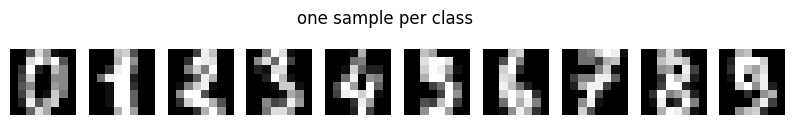

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data, digits.target  # (1797, 64)
print(X.shape)

fig, axes = plt.subplots(1, 10, figsize=(10, 1.5))
for ax, i in zip(axes, range(10)):
    ax.imshow(X[y == i][0].reshape(8, 8), cmap="gray")
    ax.set_axis_off()
plt.suptitle("one sample per class")
plt.show()

## Part 1 - SVD and low-rank reconstruction

We factor the (centered) data matrix and reconstruct digits from $k$ components:
$X_k=\sum_{j\le k}\sigma_j u_j v_j^T$. Eckart-Young says this is the *best* rank-$k$
approximation, with error $\sum_{j>k}\sigma_j^2$.

reconstruction error, direct: 565183.4, formula sum sigma_j^2: 565183.4


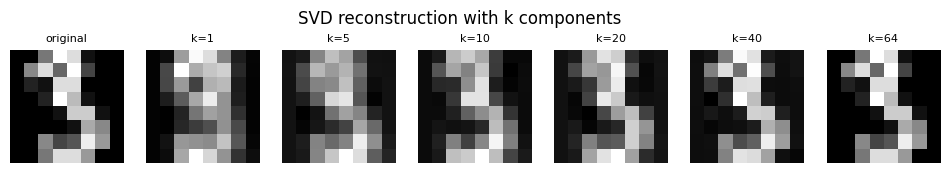

In [2]:
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

# verify the error formula numerically
k = 10
Xk = U[:, :k] @ np.diag(S[:k]) @ Vt[:k]
err_direct = np.linalg.norm(Xc - Xk) ** 2
err_formula = np.sum(S[k:] ** 2)
print(f"reconstruction error, direct: {err_direct:.1f}, formula sum sigma_j^2: {err_formula:.1f}")

sample = np.where(y == 3)[0][0]
ks = [1, 5, 10, 20, 40, 64]
fig, axes = plt.subplots(1, len(ks) + 1, figsize=(12, 2))
axes[0].imshow(X[sample].reshape(8, 8), cmap="gray"); axes[0].set_title("original", fontsize=8)
for ax, k in zip(axes[1:], ks):
    recon = X.mean(axis=0) + U[sample, :k] * S[:k] @ Vt[:k]
    ax.imshow(recon.reshape(8, 8), cmap="gray")
    ax.set_title(f"k={k}", fontsize=8)
for ax in axes:
    ax.set_axis_off()
plt.suptitle("SVD reconstruction with k components")
plt.show()

## Part 2 - PCA: spectrum and 2D projection

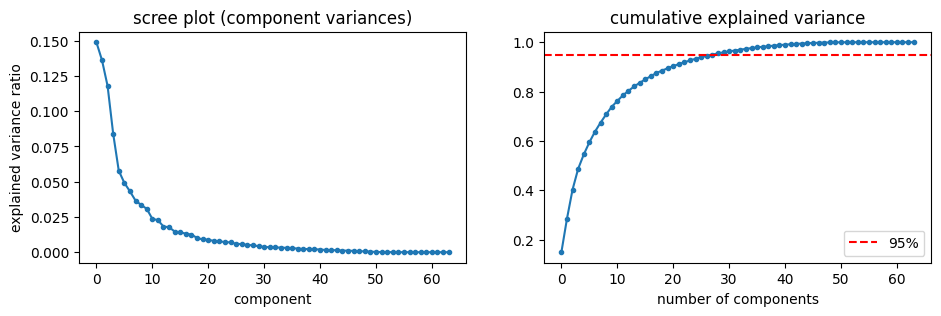

components needed for 95% variance: 29 of 64


In [3]:
pca_full = PCA().fit(X)
evr = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(evr, "o-", ms=3)
axes[0].set_title("scree plot (component variances)")
axes[0].set_xlabel("component"); axes[0].set_ylabel("explained variance ratio")
axes[1].plot(np.cumsum(evr), "o-", ms=3)
axes[1].axhline(0.95, color="r", ls="--", label="95%")
axes[1].set_title("cumulative explained variance")
axes[1].set_xlabel("number of components"); axes[1].legend()
plt.show()

n95 = int(np.searchsorted(np.cumsum(evr), 0.95)) + 1
print(f"components needed for 95% variance: {n95} of 64")

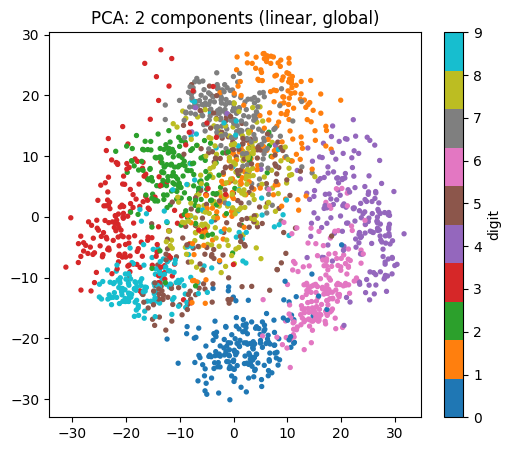

In [4]:
X_pca2 = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=y, cmap="tab10", s=8)
plt.colorbar(sc, label="digit")
plt.title("PCA: 2 components (linear, global)")
plt.show()

PCA gives an honest *global* picture (distances are meaningful, the map is a linear
projection), but classes overlap - 2 linear directions can't separate 10 digit shapes.

## Part 3 - t-SNE preserves neighborhoods

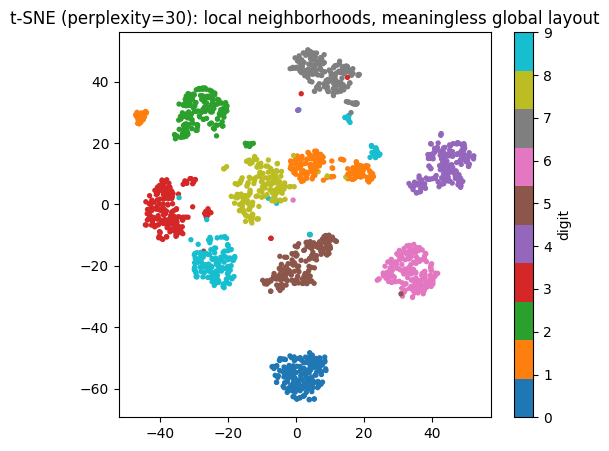

In [5]:
X_tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(X)

plt.figure(figsize=(6, 5))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=8)
plt.colorbar(sc, label="digit")
plt.title("t-SNE (perplexity=30): local neighborhoods, meaningless global layout")
plt.show()

Much cleaner clusters - but remember the lesson's warnings: cluster **sizes** and
**inter-cluster distances** here carry no meaning, and the layout changes with the seed.

### Perplexity changes the picture

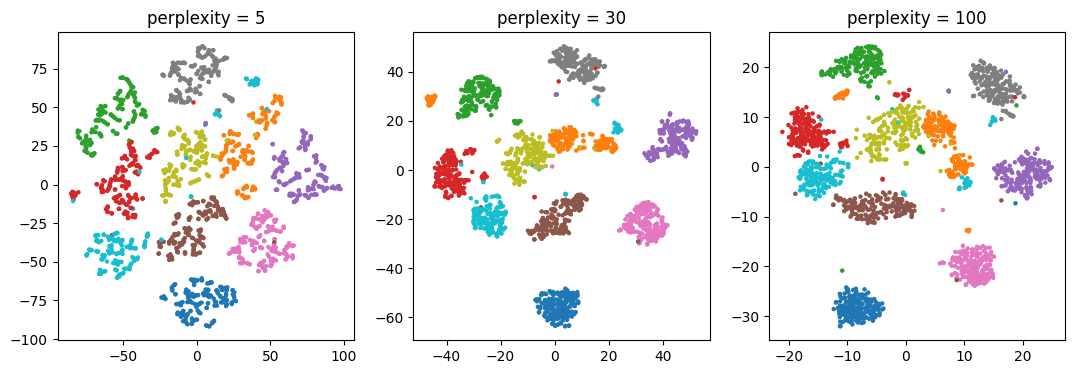

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, perp in zip(axes, [5, 30, 100]):
    emb = TSNE(n_components=2, perplexity=perp, init="pca", random_state=0).fit_transform(X)
    ax.scatter(emb[:, 0], emb[:, 1], c=y, cmap="tab10", s=5)
    ax.set_title(f"perplexity = {perp}")
plt.show()

## Part 4 - The standard recipe: PCA -> t-SNE, plus kernel PCA for contrast

Reducing to ~30 PCA dimensions first denoises and makes the k-NN graph cheaper -
this is standard practice for t-SNE/UMAP on high-dimensional data.
(UMAP is not installed here; its API is one line: `umap.UMAP(n_neighbors=15).fit_transform(X)` -
swap it in on your machine and compare.)

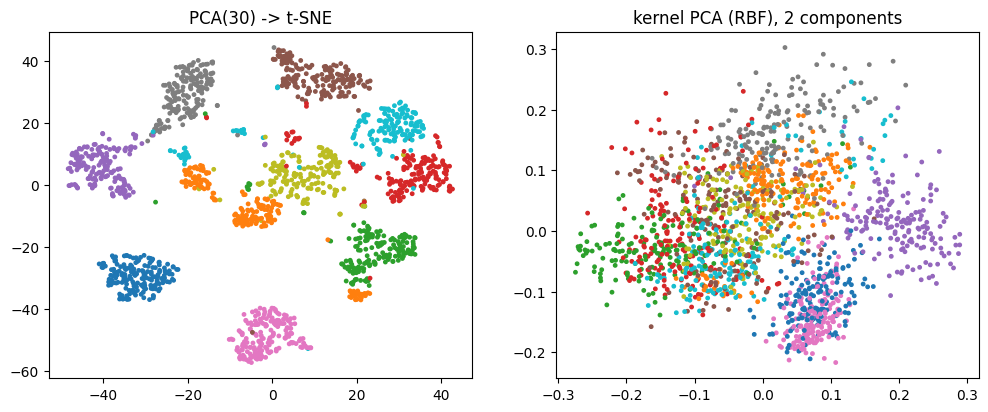

In [7]:
X_pca30 = PCA(n_components=30).fit_transform(StandardScaler().fit_transform(X))
X_tsne_pca = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(X_pca30)

X_kpca = KernelPCA(n_components=2, kernel="rbf", gamma=1e-3).fit_transform(StandardScaler().fit_transform(X))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_tsne_pca[:, 0], X_tsne_pca[:, 1], c=y, cmap="tab10", s=6)
axes[0].set_title("PCA(30) -> t-SNE")
axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap="tab10", s=6)
axes[1].set_title("kernel PCA (RBF), 2 components")
plt.show()

### TODO exercises

1. Train a logistic regression on (a) all 64 pixels, (b) 10 PCA components, (c) the 2D t-SNE
   coordinates. Compare test accuracies - why is (c) both cheating *and* worse than you'd hope?
   (Hint: t-SNE has no `transform` for unseen data - what does that force you to do?)
2. Rerun t-SNE with `random_state=1`. Which structures survive? Those are the trustworthy ones.
3. Use the scree plot to pick $k$ by the elbow rule and compare with the 95% rule.
4. Take the top-2 *supervised* directions with `LinearDiscriminantAnalysis(n_components=2)` and
   compare with PCA's unsupervised ones. Which is better for class separation, and why?